# k-Nearest Neighbors Evaluation on `dataset_stratified.csv`

This notebook evaluates a **Decision Tree classifier** on the stratified 20,000-row Covertype sample. The experiment is designed to satisfy the required analysis items:

- regularized/pruned Decision Trees using **`max_depth`** and **`min_samples_leaf`**;
- meaningful model-complexity sweep across several tree depths;
- learning curves using at least four training sizes;
- runtime table with fit and predict wall-clock times;
- multiclass evaluation using accuracy, macro-F1, balanced accuracy, confusion matrix, and per-class precision/recall/F1.

### Modeling choice

I use `criterion="gini"` because it is the standard scikit-learn default for CART-style Decision Trees, is computationally efficient, and is fully acceptable for this assignment. The main regularization is `max_depth`, supported by `min_samples_leaf=5` to avoid leaves formed from extremely small sample counts. This is appropriate for Covertype because the dataset is multiclass, imbalanced, and likely contains nonlinear interactions between terrain/elevation variables and binary wilderness/soil indicators.


> **Repository alignment:** This notebook is structured for the standalone `01-model-benchmarking-and-error-analysis` project root. Inputs are read from `data/raw/covertype/` or `data/processed/`; metrics, runtime tables, model-comparison artifacts, confusion matrices, and figures are written to the project-local `results/` and `figures/` folders.


In [1]:
# Project-local configuration, paths, and imports
import os
import sys
from pathlib import Path

MODULE_NAME = "01-model-benchmarking-and-error-analysis"
NOTEBOOK_SLUG = "04_knn_evaluation"


def _find_project_root(start: str | Path | None = None) -> Path:
    """Find the 01-model-benchmarking-and-error-analysis project root."""
    start_path = Path(start or os.environ.get("MODEL_BENCHMARK_ROOT", Path.cwd())).resolve()
    for candidate in [start_path, *start_path.parents]:
        if candidate.name == MODULE_NAME and (candidate / "notebooks").exists():
            return candidate
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "src").exists()
            and (candidate / "scripts").exists()
        ):
            return candidate
    return start_path


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src.data.project_paths import get_paths
except Exception as exc:
    raise ImportError(
        "Could not import src.data.project_paths. Run this notebook from inside "
        "01-model-benchmarking-and-error-analysis or set MODEL_BENCHMARK_ROOT."
    ) from exc

PATHS = get_paths(PROJECT_ROOT)

RAW_DATA_DIR = PATHS.raw_data_dir
PROCESSED_DATA_DIR = PATHS.processed_data_dir
DATASET_STRATIFIED_PATH = PATHS.dataset_stratified_path
DATASET_REMAINDER_PATH = PATHS.dataset_remainder_path

RESULTS_METRICS_DIR = PATHS.results_metrics_dir
RESULTS_RUNTIME_DIR = PATHS.results_runtime_dir
RESULTS_MODEL_COMPARISON_DIR = PATHS.results_model_comparison_dir
RESULTS_CONFUSION_MATRICES_DIR = PATHS.results_confusion_matrices_dir

FIG_EDA_DIR = PATHS.figures_eda_dir
FIG_LEARNING_CURVES_DIR = PATHS.figures_learning_curves_dir
FIG_MODEL_COMPLEXITY_DIR = PATHS.figures_model_complexity_dir
FIG_CONFUSION_MATRICES_DIR = PATHS.figures_confusion_matrices_dir
FIG_RUNTIME_DIR = PATHS.figures_runtime_dir

REPORTS_DIR = PATHS.reports_dir

# Backward-compatible aliases used by the original notebooks.
# New output writes below are routed to the specific category folders above.
OUT_DIR = RESULTS_METRICS_DIR
RESULTS_DIR = RESULTS_METRICS_DIR
FIG_DIR = FIG_EDA_DIR if NOTEBOOK_SLUG.startswith(("01_", "02_")) else FIG_MODEL_COMPLEXITY_DIR

for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    RESULTS_METRICS_DIR,
    RESULTS_RUNTIME_DIR,
    RESULTS_MODEL_COMPARISON_DIR,
    RESULTS_CONFUSION_MATRICES_DIR,
    FIG_EDA_DIR,
    FIG_LEARNING_CURVES_DIR,
    FIG_MODEL_COMPLEXITY_DIR,
    FIG_CONFUSION_MATRICES_DIR,
    FIG_RUNTIME_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Input protocol:
# - Notebook 01 reads raw covtype.data and creates dataset_stratified.csv + dataset_remainder.csv.
# - Notebooks 02-08 read dataset_stratified.csv for train/validation.
# - Model notebooks also read dataset_remainder.csv for untouched final testing.
DATA_PATH_RAW = RAW_DATA_DIR / "covtype.data"
DATA_PATH = DATASET_STRATIFIED_PATH
DATA_PATH_TEST = DATASET_REMAINDER_PATH
TARGET_COL = "Cover_Type"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
if NOTEBOOK_SLUG not in {'02_eda_dataset_sampled', '01_eda_dataset_original'}:
    print("DATA_PATH_TEST:", DATA_PATH_TEST)
print("Processed data:", PROCESSED_DATA_DIR)
print("Results/metrics:", RESULTS_METRICS_DIR)
print("Results/runtime:", RESULTS_RUNTIME_DIR)
print("Results/model-comparison:", RESULTS_MODEL_COMPARISON_DIR)
print("Results/confusion-matrices:", RESULTS_CONFUSION_MATRICES_DIR)
print("Figures/EDA:", FIG_EDA_DIR)
print("Figures/learning-curves:", FIG_LEARNING_CURVES_DIR)
print("Figures/model-complexity-curves:", FIG_MODEL_COMPLEXITY_DIR)
print("Figures/confusion-matrices:", FIG_CONFUSION_MATRICES_DIR)

# Core imports

import os
import sys
import time
import json
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda text: text

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42


PROJECT_ROOT: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis
DATA_PATH: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_stratified.csv
DATA_PATH_TEST: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_remainder.csv
Processed data: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed
Results/metrics: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/metrics
Results/runtime: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/runtime
Results/model-comparison: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/model-comparison
Results/confusion-matrices: /home/vision/Repos/ml-model-e

## 1. Load data and identify the target

In [2]:

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Run 01_eda_dataset_original.ipynb first so dataset_stratified.csv exists under data/processed/."
    )

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

TARGET_CANDIDATES = [
    "Cover_Type", "cover_type", "CoverType", "target", "Target", "class", "Class", "label", "Label", "y"
]

target_col = next((c for c in TARGET_CANDIDATES if c in df.columns), df.columns[-1])
print("Target column:", target_col)

X = df.drop(columns=[target_col])
y = df[target_col]

# Coerce features to numeric where possible. This dataset should already be numeric.
X = X.apply(pd.to_numeric, errors="raise")

class_counts = y.value_counts().sort_index()
class_percent = (class_counts / len(y) * 100).round(2)
class_summary = pd.DataFrame({"count": class_counts, "percent": class_percent})
print("Class distribution:")
display(class_summary)
class_summary.to_csv(RESULTS_METRICS_DIR / "01_class_distribution.csv")


Shape: (20000, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2879,7,8,810,84,2230,211,225,151,949,...,0,0,0,0,0,0,0,0,0,2
1,2630,5,23,42,9,1511,184,190,137,2021,...,0,0,0,0,0,0,0,0,0,2
2,2856,46,13,228,40,3336,224,211,119,2940,...,0,0,0,0,0,0,0,0,0,2
3,2959,311,10,443,44,2900,194,233,179,1485,...,0,0,0,0,0,0,0,0,0,2
4,2309,162,4,127,46,1019,223,240,152,860,...,0,0,0,0,0,0,0,0,0,3


Target column: Cover_Type
Class distribution:


,count,percent
Cover_Type,,
1,7292,36.46
2,9752,48.76
3,1231,6.16
4,94,0.47
5,327,1.64
6,598,2.99
7,706,3.53


## 2. Split data and scale features

The dataset is split into **60% training, 20% validation, and remainder original dataset for test** using stratification to preserve class proportions.

For kNN, feature scale matters because distance calculations are directly affected by feature magnitudes. The 10 continuous cartographic features are standardized with `StandardScaler`. The wilderness-area and soil-type one-hot indicators remain as 0/1 binary columns. This avoids artificially inflating rare binary indicators by scaling them to large standardized values, while still allowing them to contribute to Euclidean distance.


In [3]:
def is_binary_series(s: pd.Series) -> bool:
    vals = pd.Series(s.dropna().unique())
    return len(vals) <= 2 and set(vals.tolist()).issubset({0, 1, 0.0, 1.0})

binary_cols = [c for c in X.columns if is_binary_series(X[c])]
continuous_cols = [c for c in X.columns if c not in binary_cols]

print(f"Continuous columns ({len(continuous_cols)}):", continuous_cols[:15], "..." if len(continuous_cols) > 15 else "")
print(f"Binary indicator columns ({len(binary_cols)}):", binary_cols[:15], "..." if len(binary_cols) > 15 else "")

preprocessor = ColumnTransformer(
    transformers=[
        ("continuous_scaled", StandardScaler(), continuous_cols),
        ("binary_passthrough", "passthrough", binary_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)


Continuous columns (10): ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points'] 
Binary indicator columns (44): ['Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3', 'Wilderness_Area_4', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11'] ...


## 3. Train/validation/test split

I use stratified splits to preserve the class distribution. The validation set is used for model-complexity selection; the final test set is held out until the final operating point is selected.

In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,   # 0.25 of 0.80 = 0.20 of full data
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)
print("Train class counts:")
display(y_train.value_counts().sort_index().to_frame("count"))

Train: (12000, 54) Validation: (4000, 54) Test: (4000, 54)
Train class counts:


,count
Cover_Type,
1,4375
2,5851
3,739
4,56
5,197
6,358
7,424


## 4. Model-complexity curve: validation metric vs. `k`

For sweep I used seven meaningfully different values of `k`, spanning very local neighborhoods through much smoother neighborhoods: `k = [1, 3, 7, 15, 31, 63, 127]`

This range is broad enough to reveal whether the model overfits at very small `k`, improves in the middle, or underfits as neighborhoods become too large.


In [5]:
def make_knn(k: int, weights: str) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("knn", KNeighborsClassifier(
                n_neighbors=k,
                weights=weights,
                metric="minkowski",
                p=2,
                algorithm="auto",
                n_jobs=-1,
            )),
        ]
    )


def metric_dict(y_true, y_pred, prefix: str = "") -> dict:
    return {
        f"{prefix}accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

k_values = [1, 3, 7, 15, 31, 63, 127]
weight_options = ["uniform", "distance"]

records = []
for weights in weight_options:
    for k in k_values:
        model = make_knn(k, weights)
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - t0
        
        t1 = time.perf_counter()
        y_val_pred = model.predict(X_val)
        predict_seconds = time.perf_counter() - t1
        
        row = {
            "k": k,
            "weights": weights,
            "fit_seconds": fit_seconds,
            "validation_predict_seconds": predict_seconds,
            "validation_predict_ms_per_row": predict_seconds / len(X_val) * 1000,
        }
        row.update(metric_dict(y_val, y_val_pred, prefix="val_"))
        records.append(row)
        print(f"Done: weights={weights:8s}, k={k:3d}, val_macro_f1={row['val_macro_f1']:.4f}, val_bal_acc={row['val_balanced_accuracy']:.4f}")

mc_table = pd.DataFrame(records).sort_values(["weights", "k"]).reset_index(drop=True)
mc_table.to_csv(RESULTS_MODEL_COMPARISON_DIR / "02_knn_model_complexity_results.csv", index=False)
display(mc_table)

Done: weights=uniform , k=  1, val_macro_f1=0.6524, val_bal_acc=0.6447


Done: weights=uniform , k=  3, val_macro_f1=0.6036, val_bal_acc=0.5689


Done: weights=uniform , k=  7, val_macro_f1=0.5840, val_bal_acc=0.5457


Done: weights=uniform , k= 15, val_macro_f1=0.5062, val_bal_acc=0.4655


Done: weights=uniform , k= 31, val_macro_f1=0.4298, val_bal_acc=0.4020


...

Done: weights=distance, k= 15, val_macro_f1=0.5650, val_bal_acc=0.5203


Done: weights=distance, k= 31, val_macro_f1=0.4931, val_bal_acc=0.4542


Done: weights=distance, k= 63, val_macro_f1=0.3953, val_bal_acc=0.3778


Done: weights=distance, k=127, val_macro_f1=0.3422, val_bal_acc=0.3374


,k,weights,fit_seconds,validation_predict_seconds,validation_predict_ms_per_row,val_accuracy,val_macro_f1,val_balanced_accuracy
0,1,distance,0.024452,0.117736,0.029434,0.78475,0.652442,0.644711
1,3,distance,0.025384,0.127545,0.031886,0.78450,0.633326,0.616400
2,7,distance,0.025311,0.139016,0.034754,0.78475,0.617405,0.583270
3,15,distance,0.025205,0.162572,0.040643,0.77025,0.564955,0.520253
4,31,distance,0.025946,0.207867,0.051967,0.75650,0.493113,0.454230
5,63,distance,0.020313,0.293048,0.073262,0.73025,0.395338,0.377767
6,127,distance,0.021370,0.452781,0.113195,0.71175,0.342210,0.337444
7,1,uniform,0.012988,0.092070,0.023017,0.78475,0.652442,0.644711
8,3,uniform,0.012704,0.074251,0.018563,0.77325,0.603562,0.568871
9,7,uniform,0.016404,0.092043,0.023011,0.76025,0.584035,0.545721


In [6]:

## 5. Model-complexity curve

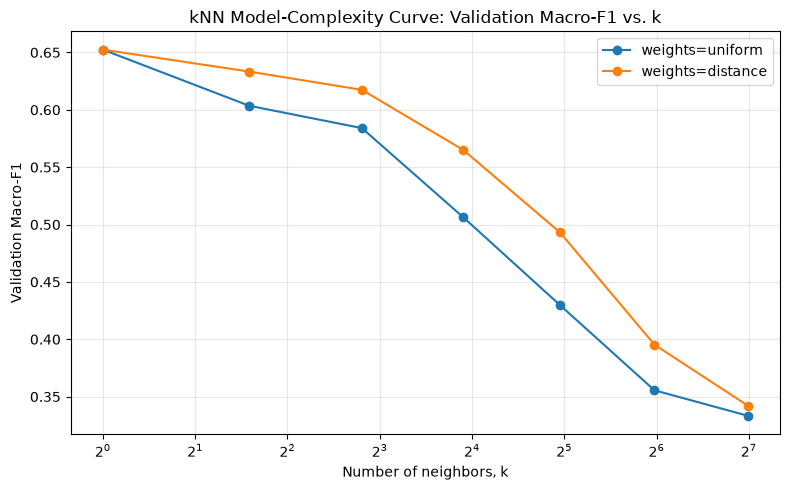

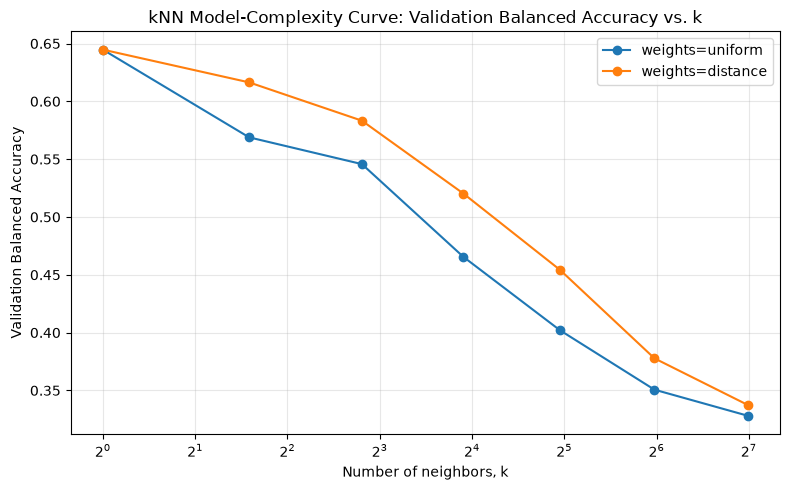

In [7]:

plt.figure(figsize=(8, 5))
for weights in weight_options:
    sub = mc_table[mc_table["weights"] == weights]
    plt.plot(sub["k"], sub["val_macro_f1"], marker="o", label=f"weights={weights}")
plt.xscale("log", base=2)
plt.xlabel("Number of neighbors, k")
plt.ylabel("Validation Macro-F1")
plt.title("kNN Model-Complexity Curve: Validation Macro-F1 vs. k")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_MODEL_COMPLEXITY_DIR / "01_knn_model_complexity_macro_f1.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
for weights in weight_options:
    sub = mc_table[mc_table["weights"] == weights]
    plt.plot(sub["k"], sub["val_balanced_accuracy"], marker="o", label=f"weights={weights}")
plt.xscale("log", base=2)
plt.xlabel("Number of neighbors, k")
plt.ylabel("Validation Balanced Accuracy")
plt.title("kNN Model-Complexity Curve: Validation Balanced Accuracy vs. k")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_MODEL_COMPLEXITY_DIR / "02_knn_model_complexity_balanced_accuracy.png", dpi=200)
plt.show()


## 6. Select operating point
The operating point I selected by validation Macro-F1 first, balanced accuracy second, and accuracy third. This avoids choosing a model that only performs well on majority classes.

In [8]:
best_row = (
    mc_table
    .sort_values(["val_macro_f1", "val_balanced_accuracy", "val_accuracy"], ascending=False)
    .iloc[0]
)

best_k = int(best_row["k"])
best_weights = str(best_row["weights"])

print("Selected operating point")
print("k:", best_k)
print("weights:", best_weights)
print(best_row.to_string())

Selected operating point
k: 1
weights: distance
k                                       1
weights                          distance
fit_seconds                      0.024452
validation_predict_seconds       0.117736
validation_predict_ms_per_row    0.029434
val_accuracy                      0.78475
val_macro_f1                     0.652442
val_balanced_accuracy            0.644711


## 7. Learning curve
The learning curve evaluates the selected operating point at four training sizes. Training and validation Macro-F1 are shown against training-set size.

Important kNN interpretation note: kNN is a lazy learner, so “fit time” is mostly preprocessing/storage. Its main computational cost occurs at prediction time, when distances to training points are computed.


In [9]:
train_fracs = [0.10, 0.30, 0.60, 1.00]
learning_records = []

for frac in train_fracs:
    if frac < 1.0:
        X_sub, _, y_sub, _ = train_test_split(
            X_train, y_train,
            train_size=frac,
            random_state=RANDOM_STATE,
            stratify=y_train,
        )
    else:
        X_sub, y_sub = X_train, y_train
    
    model = make_knn(best_k, best_weights)
    t0 = time.perf_counter()
    model.fit(X_sub, y_sub)
    fit_seconds = time.perf_counter() - t0
    
    t1 = time.perf_counter()
    y_sub_pred = model.predict(X_sub)
    train_predict_seconds = time.perf_counter() - t1
    
    t2 = time.perf_counter()
    y_val_pred = model.predict(X_val)
    val_predict_seconds = time.perf_counter() - t2
    
    row = {
        "train_fraction": frac,
        "train_size": len(X_sub),
        "fit_seconds": fit_seconds,
        "train_predict_seconds": train_predict_seconds,
        "validation_predict_seconds": val_predict_seconds,
    }
    row.update(metric_dict(y_sub, y_sub_pred, prefix="train_"))
    row.update(metric_dict(y_val, y_val_pred, prefix="val_"))
    learning_records.append(row)
    print(f"LC: frac={frac:.2f}, n={len(X_sub):5d}, train_macro_f1={row['train_macro_f1']:.4f}, val_macro_f1={row['val_macro_f1']:.4f}")

learning_table = pd.DataFrame(learning_records)
learning_table.to_csv(RESULTS_MODEL_COMPARISON_DIR / "03_knn_learning_curve_results.csv", index=False)
display(learning_table)

LC: frac=0.10, n= 1200, train_macro_f1=1.0000, val_macro_f1=0.4479
LC: frac=0.30, n= 3600, train_macro_f1=1.0000, val_macro_f1=0.5359


LC: frac=0.60, n= 7200, train_macro_f1=1.0000, val_macro_f1=0.6017


LC: frac=1.00, n=12000, train_macro_f1=1.0000, val_macro_f1=0.6524


,train_fraction,train_size,fit_seconds,train_predict_seconds,validation_predict_seconds,train_accuracy,train_macro_f1,train_balanced_accuracy,val_accuracy,val_macro_f1,val_balanced_accuracy
0,0.1,1200,0.006933,0.006431,0.010367,1.0,1.0,1.0,0.64575,0.447919,0.435175
1,0.3,3600,0.007539,0.023093,0.024296,1.0,1.0,1.0,0.69600,0.535869,0.516682
2,0.6,7200,0.010494,0.078364,0.052369,1.0,1.0,1.0,0.74875,0.601725,0.594215
3,1.0,12000,0.013933,0.275018,0.117815,1.0,1.0,1.0,0.78475,0.652442,0.644711


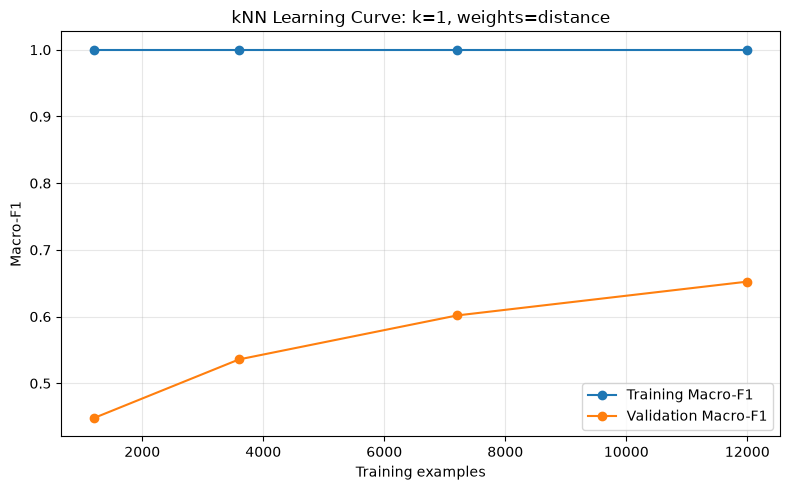

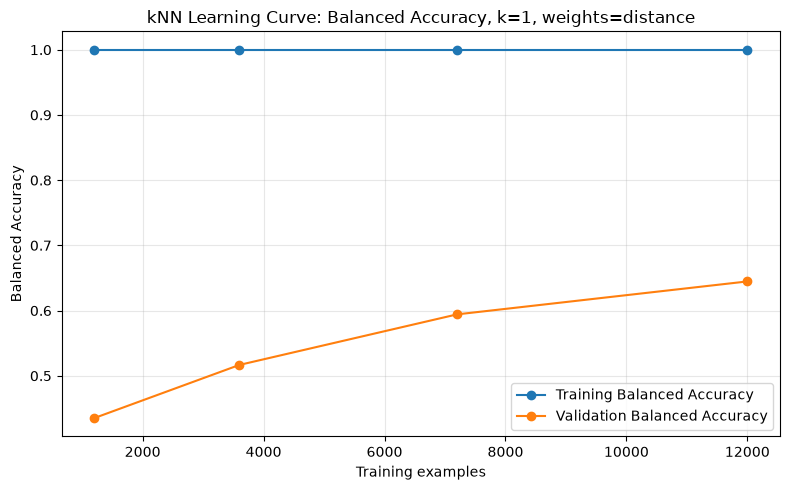

In [10]:
# plotting learning curve
plt.figure(figsize=(8, 5))
plt.plot(learning_table["train_size"], learning_table["train_macro_f1"], marker="o", label="Training Macro-F1")
plt.plot(learning_table["train_size"], learning_table["val_macro_f1"], marker="o", label="Validation Macro-F1")
plt.xlabel("Training examples")
plt.ylabel("Macro-F1")
plt.title(f"kNN Learning Curve: k={best_k}, weights={best_weights}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / "02_knn_learning_curve_macro_f1.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(learning_table["train_size"], learning_table["train_balanced_accuracy"], marker="o", label="Training Balanced Accuracy")
plt.plot(learning_table["train_size"], learning_table["val_balanced_accuracy"], marker="o", label="Validation Balanced Accuracy")
plt.xlabel("Training examples")
plt.ylabel("Balanced Accuracy")
plt.title(f"kNN Learning Curve: Balanced Accuracy, k={best_k}, weights={best_weights}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / "03_knn_learning_curve_balanced_accuracy.png", dpi=200)
plt.show()

## 6. Final test-set evaluation
After selecting the operating point from validation performance, I refit the final model on the combined train+validation data and evaluated once on the held-out test set.

In [11]:
final_model = make_knn(best_k, best_weights)

fit_start = time.perf_counter()
final_model.fit(X_train_val, y_train_val)
final_fit_seconds = time.perf_counter() - fit_start

pred_start = time.perf_counter()
y_test_pred = final_model.predict(X_test)
final_predict_seconds = time.perf_counter() - pred_start

final_metrics = metric_dict(y_test, y_test_pred, prefix="test_")
final_metrics.update({
    "selected_k": best_k,
    "selected_weights": best_weights,
    "final_fit_seconds": final_fit_seconds,
    "final_test_predict_seconds": final_predict_seconds,
    "final_test_predict_ms_per_row": final_predict_seconds / len(X_test) * 1000,
})

final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df.to_csv(RESULTS_METRICS_DIR / "04_knn_final_test_metrics.csv", index=False)
display(final_metrics_df)

report_dict = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(RESULTS_METRICS_DIR / "05_knn_per_class_classification_report.csv")
display(report_df)


,test_accuracy,test_macro_f1,test_balanced_accuracy,selected_k,selected_weights,final_fit_seconds,final_test_predict_seconds,final_test_predict_ms_per_row
0,0.80825,0.690931,0.688154,1,distance,0.015988,0.091838,0.022959


,precision,recall,f1-score,support
1,0.810453,0.797668,0.804010,1458.00000
2,0.842480,0.849821,0.846134,1951.00000
3,0.745968,0.752033,0.748988,246.00000
4,0.555556,0.526316,0.540541,19.00000
5,0.603774,0.492308,0.542373,65.00000
6,0.551181,0.583333,0.566802,120.00000
7,0.761589,0.815603,0.787671,141.00000
accuracy,0.808250,0.808250,0.808250,0.80825
macro avg,0.695857,0.688154,0.690931,4000.00000
weighted avg,0.808038,0.808250,0.807977,4000.00000


,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7
true_1,1163,261,0,0,4,1,29
true_2,242,1658,17,0,14,13,7
true_3,1,10,185,7,3,40,0
true_4,0,0,7,10,0,2,0
true_5,3,22,7,0,32,1,0
true_6,1,16,32,1,0,70,0
true_7,25,1,0,0,0,0,115


<Figure size 800x700 with 0 Axes>

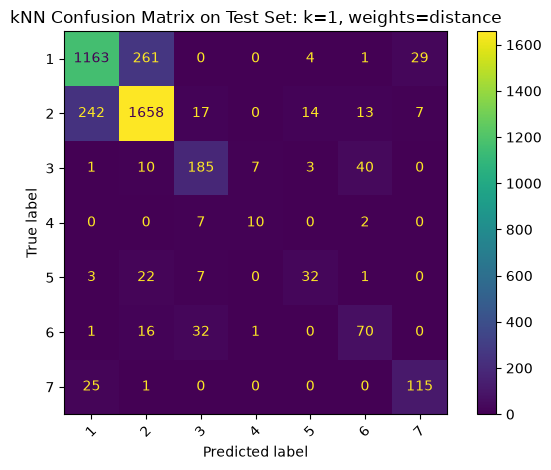

In [12]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in labels], columns=[f"pred_{c}" for c in labels])
cm_df.to_csv(RESULTS_CONFUSION_MATRICES_DIR / "06_knn_confusion_matrix.csv")
display(cm_df)

plt.figure(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d", xticks_rotation=45)
plt.title(f"kNN Confusion Matrix on Test Set: k={best_k}, weights={best_weights}")
plt.tight_layout()
plt.savefig(FIG_CONFUSION_MATRICES_DIR / "04_knn_confusion_matrix.png", dpi=200)
plt.show()

## 7. Runtime table and hardware note
For kNN, fit time is not the main cost because the algorithm stores the training data. Prediction time is more important and grows with the number of training examples, number of features, and number of validation/test examples.


In [13]:
def hardware_note() -> dict:
    note = {
        "platform": platform.platform(),
        "python_version": platform.python_version(),
        "processor": platform.processor(),
        "cpu_count_logical": os.cpu_count(),
    }
    try:
        import psutil
        note["memory_gb"] = round(psutil.virtual_memory().total / (1024**3), 2)
    except Exception:
        note["memory_gb"] = "psutil unavailable"
    return note

runtime_rows = []
for _, row in mc_table.iterrows():
    runtime_rows.append({
        "phase": "validation_model_complexity",
        "k": int(row["k"]),
        "weights": row["weights"],
        "fit_seconds": row["fit_seconds"],
        "predict_seconds": row["validation_predict_seconds"],
        "predict_ms_per_row": row["validation_predict_ms_per_row"],
    })

runtime_rows.append({
    "phase": "final_test",
    "k": best_k,
    "weights": best_weights,
    "fit_seconds": final_fit_seconds,
    "predict_seconds": final_predict_seconds,
    "predict_ms_per_row": final_predict_seconds / len(X_test) * 1000,
})

runtime_table = pd.DataFrame(runtime_rows)
runtime_table.to_csv(RESULTS_RUNTIME_DIR / "07_knn_runtime_table.csv", index=False)
display(runtime_table)

note = hardware_note()
with open(RESULTS_RUNTIME_DIR / "08_hardware_note.json", "w") as f:
    json.dump(note, f, indent=2)
print(json.dumps(note, indent=2))

,phase,k,weights,fit_seconds,predict_seconds,predict_ms_per_row
0,validation_model_complexity,1,distance,0.024452,0.117736,0.029434
1,validation_model_complexity,3,distance,0.025384,0.127545,0.031886
2,validation_model_complexity,7,distance,0.025311,0.139016,0.034754
3,validation_model_complexity,15,distance,0.025205,0.162572,0.040643
4,validation_model_complexity,31,distance,0.025946,0.207867,0.051967
5,validation_model_complexity,63,distance,0.020313,0.293048,0.073262
6,validation_model_complexity,127,distance,0.021370,0.452781,0.113195
7,validation_model_complexity,1,uniform,0.012988,0.092070,0.023017
8,validation_model_complexity,3,uniform,0.012704,0.074251,0.018563
9,validation_model_complexity,7,uniform,0.016404,0.092043,0.023011


{
  "platform": "Linux-6.8.0-124-generic-x86_64-with-glibc2.39",
  "python_version": "3.11.15",
  "processor": "x86_64",
  "cpu_count_logical": 12,
  "memory_gb": 15.29
}


## 8. Report-ready discussion

The following cell prints a concise interpretation using the actual metrics computed above.


In [14]:
# Build concise, report-ready text from computed tables.
final_acc = final_metrics_df.loc[0, 'test_accuracy']
final_macro = final_metrics_df.loc[0, 'test_macro_f1']
final_bal = final_metrics_df.loc[0, 'test_balanced_accuracy']

best_val_macro = best_row['val_macro_f1']
small_k_row = mc_table[(mc_table['k'] == min(k_values)) & (mc_table['weights'] == best_weights)].iloc[0]
large_k_row = mc_table[(mc_table['k'] == max(k_values)) & (mc_table['weights'] == best_weights)].iloc[0]

minority_classes = class_summary.sort_values('count').head(3).index.tolist()
minority_report = report_df.loc[[str(c) for c in minority_classes], ['precision', 'recall', 'f1-score', 'support']]

last_lc = learning_table.iloc[-1]
first_lc = learning_table.iloc[0]

text = f'''
### Summary interpretation

The selected kNN operating point was **k={best_k} with {best_weights} weighting**, chosen by validation Macro-F1 with balanced accuracy as the secondary criterion. On the held-out test set it achieved **accuracy={final_acc:.4f}**, **Macro-F1={final_macro:.4f}**, and **balanced accuracy={final_bal:.4f}**. Accuracy summarizes total correctness, but Macro-F1 and balanced accuracy are more important here because Covertype is multiclass and imbalanced. Macro-F1 gives each class equal weight in the F1 average, while balanced accuracy averages recall across classes so that majority classes cannot dominate the evaluation.

The model-complexity curve shows how neighborhood size controls the bias-variance tradeoff. Very small neighborhoods, such as k={min(k_values)}, are more local and higher variance; very large neighborhoods, such as k={max(k_values)}, smooth across broader regions and can underfit minority or locally clustered classes. The best validation Macro-F1 of **{best_val_macro:.4f}** occurred at the selected operating point rather than assuming a default k.

The learning curve increased from validation Macro-F1 **{first_lc['val_macro_f1']:.4f}** at {int(first_lc['train_size'])} training examples to **{last_lc['val_macro_f1']:.4f}** at {int(last_lc['train_size'])} training examples. The gap between training and validation metrics indicates the amount of variance. If validation performance is still rising at the largest training size, more data is likely to help; if it has flattened while the train-validation gap remains large, model variance and feature/distance limitations are more likely than data volume alone.

The confusion matrix should be read together with the per-class report. The minority classes in this sample are {minority_classes}. Their per-class precision, recall, and F1 scores are displayed below; these values are more informative than overall accuracy for diagnosing whether the model is failing smaller cover-type classes.

kNN is sensitive to irrelevant or weakly informative features because all features contribute to distance. The 44 binary wilderness/soil indicators increase dimensionality and can dilute distance concentration, especially if some indicators are sparse or weakly related to the target. Leaving binary indicators as 0/1 while scaling only continuous features is a compromise: continuous variables do not dominate because of raw magnitude, and rare binary indicators are not artificially expanded by standardization. In a stronger extension, feature selection, learned metric weighting, PCA, or separate treatment of continuous and categorical/binary features could be tested.

Runtime behavior is also important. kNN has low fit time because it mainly stores the training data, but prediction is comparatively expensive because each validation or test point requires nearest-neighbor search against the stored examples. This is visible in the runtime table, where prediction dominates fitting.
'''

display(Markdown(text))
print('Minority-class report:')
runtime_table.to_csv(RESULTS_METRICS_DIR / "01_minority_report.csv", index=False)
display(minority_report)



### Summary interpretation

The selected kNN operating point was **k=1 with distance weighting**, chosen by validation Macro-F1 with balanced accuracy as the secondary criterion. On the held-out test set it achieved **accuracy=0.8083**, **Macro-F1=0.6909**, and **balanced accuracy=0.6882**. Accuracy summarizes total correctness, but Macro-F1 and balanced accuracy are more important here because Covertype is multiclass and imbalanced. Macro-F1 gives each class equal weight in the F1 average, while balanced accuracy averages recall across classes so that majority classes cannot dominate the evaluation.

The model-complexity curve shows how neighborhood size controls the bias-variance tradeoff. Very small neighborhoods, such as k=1, are more local and higher variance; very large neighborhoods, such as k=127, smooth across broader regions and can underfit minority or locally clustered classes. The best validation Macro-F1 of **0.6524** occurred at the selected operating point rather than assuming a default k.

The learning curve increased from validation Macro-F1 **0.4479** at 1200 training examples to **0.6524** at 12000 training examples. The gap between training and validation metrics indicates the amount of variance. If validation performance is still rising at the largest training size, more data is likely to help; if it has flattened while the train-validation gap remains large, model variance and feature/distance limitations are more likely than data volume alone.

The confusion matrix should be read together with the per-class report. The minority classes in this sample are [4, 5, 6]. Their per-class precision, recall, and F1 scores are displayed below; these values are more informative than overall accuracy for diagnosing whether the model is failing smaller cover-type classes.

kNN is sensitive to irrelevant or weakly informative features because all features contribute to distance. The 44 binary wilderness/soil indicators increase dimensionality and can dilute distance concentration, especially if some indicators are sparse or weakly related to the target. Leaving binary indicators as 0/1 while scaling only continuous features is a compromise: continuous variables do not dominate because of raw magnitude, and rare binary indicators are not artificially expanded by standardization. In a stronger extension, feature selection, learned metric weighting, PCA, or separate treatment of continuous and categorical/binary features could be tested.

Runtime behavior is also important. kNN has low fit time because it mainly stores the training data, but prediction is comparatively expensive because each validation or test point requires nearest-neighbor search against the stored examples. This is visible in the runtime table, where prediction dominates fitting.


Minority-class report:


,precision,recall,f1-score,support
4,0.555556,0.526316,0.540541,19.0
5,0.603774,0.492308,0.542373,65.0
6,0.551181,0.583333,0.566802,120.0
